# A2 extra — Semi-integral voltammetry: peak → wave

*Standalone demonstrator for Appendix 2 (see `../A2_semiintegration.ipynb`).*

A planar diffusion-limited cyclic/linear-sweep voltammogram is **peak-shaped**:
the current rises as the surface concentration is depleted, then falls off with
the $t^{-1/2}$ Cottrell tail. **Semi-integral voltammetry** (Oldham,
*Anal. Chem.* **44** (1972) 196) applies the operator $D^{-1/2}$ to the current,
which removes that diffusion tail and converts the peak into a **sigmoidal,
steady-state-like wave** — exactly the shape you would measure at a
microelectrode or rotating disk. The plateau of the wave is proportional to bulk
concentration; its half-wave potential is $E^0$ (for a reversible couple).

This notebook generates a reversible LSV current analytically (no `.dat` data),
semi-integrates it, and verifies the wave is a true Nernst sigmoid.


In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('../..'))
# %matplotlib inline embeds figures and makes plt.show() a harmless no-op under headless (Agg) execution
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from serm.semiintegration import semi_integrate, semi_derivative


## Build a reversible LSV current

For a reversible couple swept linearly in potential the surface follows Nernst,
so the cumulative reduced fraction is the logistic sigmoid
$\theta=1/(1+e^{p})$, $p=nF(E-E^0)/RT$. By the convolutive-voltammetry relation
the LSV **current** is the semi-derivative of that cumulative response,
$i_{\mathrm{LSV}}=D^{+1/2}\theta$ — a genuine reversible current function,
peak-shaped with the asymmetric diffusion tail.


In [2]:
p = np.linspace(8.0, -8.0, 8000)       # nF(E-E0)/RT, cathodic sweep
tau = np.linspace(0.0, 1.0, p.size)
dtau = tau[1] - tau[0]
theta = 1.0 / (1.0 + np.exp(p))        # Nernst sigmoid (cumulative reduced fraction)
i_lsv = semi_derivative(theta, dtau)   # diffusion-limited reversible LSV current
wave  = semi_integrate(i_lsv, dtau)    # semi-integral -> steady-state-like wave


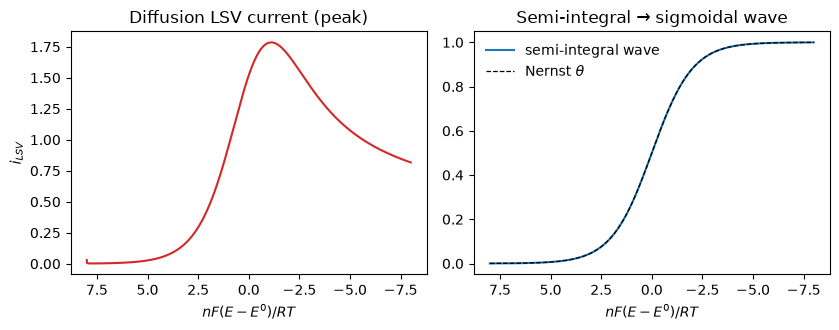

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(8.5, 3.4))
ax[0].plot(p, i_lsv, color="C3"); ax[0].invert_xaxis()
ax[0].set(title="Diffusion LSV current (peak)", xlabel="$nF(E-E^0)/RT$", ylabel="$i_{LSV}$")
ax[1].plot(p, wave, color="C0", label="semi-integral wave")
ax[1].plot(p, theta, ls="--", color="k", lw=0.9, label=r"Nernst $\theta$")
ax[1].invert_xaxis(); ax[1].legend(frameon=False)
ax[1].set(title="Semi-integral → sigmoidal wave", xlabel="$nF(E-E^0)/RT$")
fig.tight_layout(); plt.show()


## Validation

**Tier 1/3 — round-trip identity.** Because $D^{-1/2}D^{+1/2}=\mathrm{id}$, the
semi-integral of the LSV current must reproduce the Nernst sigmoid $\theta$. We
require correlation $>0.999$, a plateau approaching 1, and a half-wave potential
at $p=0$ (i.e. $E=E^0$). The half-wave location is an **independent** analytic
landmark of the reversible Nernst wave.


In [4]:
sl = slice(20, None)
corr = np.corrcoef(wave[sl], theta[sl])[0, 1]
assert corr > 0.999, f"round-trip correlation too low: {corr:.4f}"
assert abs(wave[-1] - 1.0) < 2e-2, "wave plateau did not reach 1"

# Half-wave point: wave crosses half its plateau at p = 0 (E = E0).
half = wave[-1] / 2.0
i_half = int(np.argmin(np.abs(wave - half)))
assert abs(p[i_half]) < 0.1, f"E_1/2 not at E0: p = {p[i_half]:.3f}"
print(f"correlation = {corr:.6f};  E_1/2 at p = {p[i_half]:.4f} (= E0)")
print("Tier 1/3 checks passed: semi-integral of LSV is the Nernst sigmoid.")


correlation = 1.000000;  E_1/2 at p = 0.0010 (= E0)
Tier 1/3 checks passed: semi-integral of LSV is the Nernst sigmoid.


<!-- nav-footer -->

---

[← Appendix 2 — Semi-integration and fractional calculus](../A2_semiintegration.ipynb)

[Contents (README)](../../README.md)